# 2026 实验7 调用Renet模型参数搭建CNN分类网络

## 读取数据

In [13]:
import os
from skimage.io import imread
import numpy as np
from skimage.transform import resize

def read_UC(folder_path):
    # 读取文件夹内所有子文件夹的名称
    subfolders = sorted([name for name in os.listdir(folder_path) 
                         if os.path.isdir(os.path.join(folder_path, name))])

    # 初始化变量
    X = []
    Y = []

    # 遍历每个子文件夹
    for index, subfolder in enumerate(subfolders):
        # 获取子文件夹的路径和类别编号
        subfolder_path = os.path.join(folder_path, subfolder)
        label = index
        
        # 遍历子文件夹内的所有tif图像
        for filename in os.listdir(subfolder_path):
            if filename.endswith('.tif'):
                # 读取图像数据
                image_path = os.path.join(subfolder_path, filename)
                image = imread(image_path)
                image=resize(image,(64,64,3))#为了加快训练，减小图像尺寸
                image = np.transpose(image,(2,0,1)) 
                # 将图像数据添加到X变量中
                X.append(image)
                
                # 将类别编号添加到Y变量中
                Y.append(label)

    # 将X和Y转换为NumPy数组
    X = np.array(X)
    Y = np.array(Y)

    # 打印数据维度
    print('图像数据维度:', X.shape)
    print('标签数据维度:', Y.shape)

    return X,Y

In [14]:
import torch
from torch import nn
import numpy as np

# 文件夹路径
# folder_path = '../UCMerced_LandUse/train'

# 读取训练集和测试集数据
[train_img, train_lb] = read_UC('../UCMerced_LandUse/train')
[test_img, test_lb] = read_UC('../UCMerced_LandUse/validation')


# 将所有数据归一化到0-1之间
# train_img =train_img/255.
# test_img  =test_img/255.

# 对标签进行热编码
one_hot_train_lb = np.eye(9)[train_lb]
one_hot_test_lb= np.eye(9)[test_lb]

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape,'热编码训练集标签格式为:', one_hot_train_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape,'热编码测试集标签格式为:', one_hot_test_lb.shape)
print('训练集最大值为:', np.max(train_img), '训练集最小值为:', np.min(train_img))
print('测试集最大值为:', np.max(test_img), '测试集最小值为:', np.min(test_img))

图像数据维度: (720, 3, 64, 64)
标签数据维度: (720,)
图像数据维度: (180, 3, 64, 64)
标签数据维度: (180,)
训练集图像格式为: (720, 3, 64, 64) 训练集标签格式为: (720,) 热编码训练集标签格式为: (720, 9)
测试集图像格式为: (180, 3, 64, 64) 测试集标签格式为: (180,) 热编码测试集标签格式为: (180, 9)
训练集最大值为: 1.0 训练集最小值为: 0.0
测试集最大值为: 1.0 测试集最小值为: 0.001105564213213035


## 使用部分resnet18卷积层——搭建自己的网络

###   要求1：使用Resnet18中的(conv1)、(bn1)、(relu)、(maxpool)层+(layer1)块+(layer2)块中的(conv1)、(bn1)、(relu)+两个自己的全连接层，组成分类网络，成功训练/测试


In [15]:
import torchvision.models as models
models.resnet18(weights='IMAGENET1K_V1')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [29]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.w1 =nn.Linear(8 * 8 * 128, 100)
        self.w2 =nn.Linear(100, 9)
        self.BN3=nn.BatchNorm1d(100)
        self.relu=nn.ReLU()

        self.Resnet=models.resnet18(weights='IMAGENET1K_V1')

    def forward(self, x):
        x = self.Resnet.conv1(x)
        x = self.Resnet.bn1(x)
        x = self.Resnet.relu(x)
        x = self.Resnet.maxpool(x)
        
        x = self.Resnet.layer1(x)
        
        x = self.Resnet.layer2[0].conv1(x)
        x = self.Resnet.layer2[0].bn1(x)
        x = self.Resnet.layer2[0].relu(x)
        
        x = x.view(x.size(0), -1)
        x = self.w1(x)
        x = self.BN3(x)
        x = self.relu(x)
        x = self.w2(x)
    
        return x

### 训练网络

In [30]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor()
])

model = NeuralNetwork()
loss_fn = nn.CrossEntropyLoss()
learning_rate = 2e-3
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

batch_size = 80
epochs = 20
batch_num = int(train_img.shape[0] / batch_size)
old_correct = 0.

model.train()
for t in range(epochs):
    
    # 每个 epoch 打乱索引
    shuffle_idx = np.random.permutation(train_img.shape[0])
    
    correct = 0.
    train_mean_loss = 0.

    for batch in range(batch_num):
        batch_idx = shuffle_idx[batch * batch_size : (batch + 1) * batch_size]
        
        imgs = train_img[batch_idx]
        ys = train_lb[batch_idx]  # 直接用原始标签，不需要 one_hot

        batch_X = []
        for img in imgs:
            img_hwc = np.transpose(img, (1, 2, 0))  # (C,H,W) -> (H,W,C) 给 PIL 用
            img_pil = Image.fromarray((img_hwc * 255).astype(np.uint8))  # 转成 PIL 图像
            img_tensor = transform(img_pil)  # 实时增强 + 自动转回 (C,H,W) tensor
            batch_X.append(img_tensor)
        
        X = torch.stack(batch_X)  # 拼成 (batch, C, H, W)
        y = torch.tensor(ys, dtype=torch.long)  # CrossEntropyLoss 用 long 类型
        
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        correct += (pred.argmax(1) == y).type(torch.float).mean().item()
        train_mean_loss += loss.item()

    train_mean_loss /= batch_num
    correct /= batch_num
    
    if correct > old_correct:
        torch.save(model.state_dict(), "cnn_classification.pth")

    print(f" Epoch:{t+1}, loss: {train_mean_loss:>8f}, Accuracy: {(100*correct):>0.1f}%")
    old_correct = correct

 Epoch:1, loss: 2.146658, Accuracy: 20.1%
 Epoch:2, loss: 1.631263, Accuracy: 52.2%
 Epoch:3, loss: 1.287961, Accuracy: 70.0%
 Epoch:4, loss: 1.074034, Accuracy: 79.2%
 Epoch:5, loss: 0.956624, Accuracy: 81.5%
 Epoch:6, loss: 0.846350, Accuracy: 85.6%
 Epoch:7, loss: 0.792660, Accuracy: 85.0%
 Epoch:8, loss: 0.728388, Accuracy: 87.9%
 Epoch:9, loss: 0.650139, Accuracy: 89.3%
 Epoch:10, loss: 0.597302, Accuracy: 90.1%
 Epoch:11, loss: 0.546646, Accuracy: 90.8%
 Epoch:12, loss: 0.508271, Accuracy: 91.0%
 Epoch:13, loss: 0.477277, Accuracy: 92.2%
 Epoch:14, loss: 0.443603, Accuracy: 92.5%
 Epoch:15, loss: 0.398134, Accuracy: 94.2%
 Epoch:16, loss: 0.378730, Accuracy: 94.2%
 Epoch:17, loss: 0.355004, Accuracy: 93.9%
 Epoch:18, loss: 0.351740, Accuracy: 94.3%
 Epoch:19, loss: 0.342045, Accuracy: 94.0%
 Epoch:20, loss: 0.328263, Accuracy: 94.0%


### 测试CNN在测试数据集上的Performance

In [31]:
torch.load("resnet_classification.pth", weights_only=False)

model.eval()
test_loss, correct = 0, 0
with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        
        test_loss = np.mean(loss_fn(pred, y).item())
        correct = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Test Accuracy: {(100*correct):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")

Test Accuracy: 91.1%, Test Avg loss: 0.306401 



## 要求2： 对比与3层卷积CNN网络的分类性能差异。

In [54]:
class ThreeLayerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1=nn.Conv2d(3,32,3,stride=1,padding=1)
        self.conv2=nn.Conv2d(32,64,3,stride=1,padding=1)
        self.conv3=nn.Conv2d(64,128,3,stride=1,padding=1)
        
        self.bn1=nn.BatchNorm2d(32)
        self.bn2=nn.BatchNorm2d(64)
        self.bn3=nn.BatchNorm2d(128)
        
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(0.5)
        self.pool=nn.MaxPool2d(2,2)
        
        self.fc1 =nn.Linear(8 * 8 * 128, 256)
        self.fc2 =nn.Linear(256, 9)
        
    def forward(self,x):
        x=self.conv1(x)
        x=self.bn1(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.conv2(x)
        x=self.bn2(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.conv3(x)
        x=self.bn3(x)
        x=self.relu(x)
        x=self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [55]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor()
])

model = ThreeLayerCNN()
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

batch_size = 75
epochs = 30
batch_num = int(train_img.shape[0] / batch_size)
old_correct = 0.

model.train()
for t in range(epochs):
    
    # 每个 epoch 打乱索引
    shuffle_idx = np.random.permutation(train_img.shape[0])
    
    correct = 0.
    train_mean_loss = 0.

    for batch in range(batch_num):
        batch_idx = shuffle_idx[batch * batch_size : (batch + 1) * batch_size]
        
        imgs = train_img[batch_idx]
        ys = train_lb[batch_idx]

        batch_X = []
        for img in imgs:
            img_hwc = np.transpose(img, (1, 2, 0))  # (C,H,W) -> (H,W,C) 给 PIL 用
            img_pil = Image.fromarray((img_hwc * 255).astype(np.uint8))  # 转成 PIL 图像
            img_tensor = transform(img_pil)  # 实时增强 + 自动转回 (C,H,W) tensor
            batch_X.append(img_tensor)
        
        X = torch.stack(batch_X)  # 拼成 (batch, C, H, W)
        y = torch.tensor(ys, dtype=torch.long)  # CrossEntropyLoss 用 long 类型
        
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        correct += (pred.argmax(1) == y).type(torch.float).mean().item()
        train_mean_loss += loss.item()

    train_mean_loss /= batch_num
    correct /= batch_num
    
    if correct > old_correct:
        torch.save(model.state_dict(), "cnn_classification.pth")

    print(f" Epoch:{t+1}, loss: {train_mean_loss:>8f}, Accuracy: {(100*correct):>0.1f}%")
    old_correct = correct


 Epoch:1, loss: 2.013936, Accuracy: 25.2%
 Epoch:2, loss: 1.619072, Accuracy: 41.3%
 Epoch:3, loss: 1.404318, Accuracy: 47.6%
 Epoch:4, loss: 1.287175, Accuracy: 55.9%
 Epoch:5, loss: 1.169985, Accuracy: 56.9%
 Epoch:6, loss: 1.111318, Accuracy: 63.0%
 Epoch:7, loss: 1.089231, Accuracy: 63.4%
 Epoch:8, loss: 1.042202, Accuracy: 64.4%
 Epoch:9, loss: 0.978373, Accuracy: 65.8%
 Epoch:10, loss: 0.979002, Accuracy: 67.9%
 Epoch:11, loss: 0.932499, Accuracy: 69.0%
 Epoch:12, loss: 0.901476, Accuracy: 68.3%
 Epoch:13, loss: 0.896035, Accuracy: 67.4%
 Epoch:14, loss: 0.862840, Accuracy: 70.7%
 Epoch:15, loss: 0.810515, Accuracy: 74.4%
 Epoch:16, loss: 0.762598, Accuracy: 77.5%
 Epoch:17, loss: 0.784548, Accuracy: 72.9%
 Epoch:18, loss: 0.746834, Accuracy: 72.6%
 Epoch:19, loss: 0.792212, Accuracy: 72.0%
 Epoch:20, loss: 0.732645, Accuracy: 73.8%
 Epoch:21, loss: 0.704345, Accuracy: 75.6%
 Epoch:22, loss: 0.638558, Accuracy: 78.2%
 Epoch:23, loss: 0.706560, Accuracy: 75.4%
 Epoch:24, loss: 0.6

In [56]:
torch.load("cnn_classification.pth", weights_only=False)

model.eval()
test_loss, correct = 0, 0
with torch.no_grad():
        X=torch.tensor(test_img, dtype=torch.float32)
        y=torch.tensor(one_hot_test_lb, dtype=torch.float32)
        pred = model(X)
        
        test_loss = np.mean(loss_fn(pred, y).item())
        correct = (pred.argmax(1) == y.argmax(1)).type(torch.float).mean().item()
print(f"Test Accuracy: {(100*correct):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")

Test Accuracy: 84.4%, Test Avg loss: 0.536708 



## 要求3： 将数据读取部分，修改为使用Datasets和Dataloader。

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

# 定义自定义 Dataset 类
class UCMercedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        """
        Args:
            images (numpy.ndarray): 图像数据, shape (N, C, H, W)
            labels (numpy.ndarray): 标签数据, shape (N,)
            transform (callable, optional): 可选的数据增强变换
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # 如果 transform 中包含 ToPILImage，我们需要先调整维度
        if self.transform:
            # 将 (C, H, W) 转换为 (H, W, C) 以兼容 ToPILImage
            image_hwc = np.transpose(image, (1, 2, 0))

            # 后续的 ToTensor() 会将 PIL 图像转回 Tensor (C, H, W) 并归一化到 [0,1]
            image = self.transform(image_hwc)
        else:
            # 如果没有 transform，手动转换为 Tensor
            image = torch.tensor(image, dtype=torch.float32)
            
        label = torch.tensor(label, dtype=torch.long)
        
        return image, label

# 训练集需要数据增强
train_transform = transforms.Compose([
    transforms.ToPILImage(), # 输入需为 (H, W, C) 的 numpy array 或 PIL Image
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),   # 转回 Tensor (C, H, W)，值域 [0, 1]
])

# 测试集只需要转换为 Tensor
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

# 创建 Dataset 实例
train_dataset = UCMercedDataset(train_img, train_lb, transform=train_transform)
test_dataset = UCMercedDataset(test_img, test_lb, transform=test_transform)

# 创建 DataLoader
batch_size = 100

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集图像格式为：{train_img.shape}, 训练集标签格式为：{train_lb.shape}")
print(f"测试集图像格式为：{test_img.shape}, 测试集标签格式为：{test_lb.shape}")

训练集图像格式为：(720, 3, 64, 64), 训练集标签格式为：(720,)
测试集图像格式为：(180, 3, 64, 64), 测试集标签格式为：(180,)


### 训练

In [33]:
model = NeuralNetwork()
loss_fn = nn.CrossEntropyLoss()

lr = 5e-3
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

epochs = 15
model.train()

for t in range(epochs):
    correct = 0
    train_mean_loss = 0
    batch_count = 0
    
    # 使用 DataLoader 迭代
    for X, y in train_loader:
        
        pred = model(X)
        loss = loss_fn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        train_mean_loss += loss.item()
        batch_count += 1
        
    train_mean_loss /= batch_count
    accuracy = correct / len(train_dataset)
    
    print(f" Epoch:{t+1}, loss: {train_mean_loss:>8f},  Accuracy: {(100*accuracy):>0.1f}%")

torch.save(model, "resnet_classification_dataloader.pth")

 Epoch:1, loss: 2.022095,  Accuracy: 25.4%
 Epoch:2, loss: 1.342514,  Accuracy: 66.1%
 Epoch:3, loss: 1.056244,  Accuracy: 74.0%
 Epoch:4, loss: 0.905360,  Accuracy: 77.9%
 Epoch:5, loss: 0.744356,  Accuracy: 82.4%
 Epoch:6, loss: 0.624568,  Accuracy: 87.1%
 Epoch:7, loss: 0.558475,  Accuracy: 89.7%
 Epoch:8, loss: 0.480586,  Accuracy: 89.3%
 Epoch:9, loss: 0.416096,  Accuracy: 92.2%
 Epoch:10, loss: 0.375177,  Accuracy: 93.1%
 Epoch:11, loss: 0.335698,  Accuracy: 92.1%
 Epoch:12, loss: 0.315351,  Accuracy: 93.8%
 Epoch:13, loss: 0.280600,  Accuracy: 95.4%
 Epoch:14, loss: 0.289317,  Accuracy: 93.3%
 Epoch:15, loss: 0.263190,  Accuracy: 92.9%


In [34]:
torch.load("resnet_classification_dataloader.pth", weights_only=False)
model.eval()

test_loss, correct = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
test_loss /= len(test_loader)
accuracy = correct / len(test_dataset)
print(f"Test Accuracy: {(100*accuracy):>0.1f}%, Test Avg loss: {test_loss:>8f} \n")

Test Accuracy: 92.8%, Test Avg loss: 0.261675 



## 实验结果

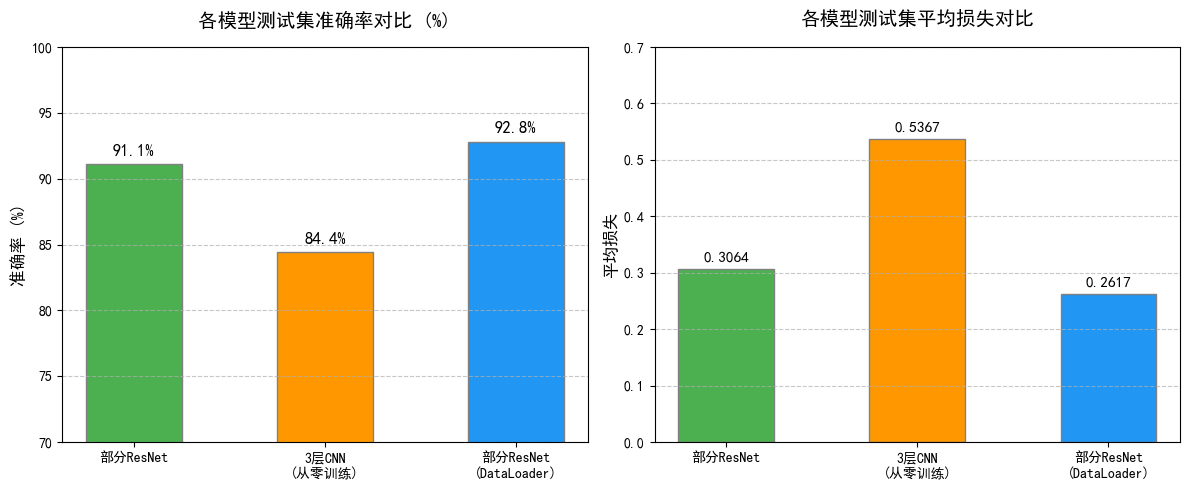

           实验结果数据汇总对比表
模型名称                 | 测试准确率        | 测试平均损失      
------------------------------------------------------------
部分ResNet(手动循环)     |     91.1%    |   0.306401
3层CNN(从零训练)       |     84.4%    |   0.536708
部分ResNet(DataLoader) |     92.8%    |   0.261675


In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 根据实验输出提取的测试集结果数据
models = ['部分ResNet\n', '3层CNN\n(从零训练)', '部分ResNet\n(DataLoader)']
test_accuracies = [91.1, 84.4, 92.8]
test_losses = [0.306401, 0.536708, 0.261675]

# 创建一个 1x2 的子图布局
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------- 绘制测试准确率对比图 ----------------
colors_acc = ['#4CAF50', '#FF9800', '#2196F3']
bars_acc = axes[0].bar(models, test_accuracies, color=colors_acc, width=0.5, edgecolor='grey')
axes[0].set_title('各模型测试集准确率对比 (%)', fontsize=14, pad=15)
axes[0].set_ylabel('准确率 (%)', fontsize=12)
axes[0].set_ylim([70, 100]) # 固定Y轴范围以突出差异
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值标签
for bar in bars_acc:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---------------- 绘制测试损失对比图 ----------------
colors_loss = ['#4CAF50', '#FF9800', '#2196F3']
bars_loss = axes[1].bar(models, test_losses, color=colors_loss, width=0.5, edgecolor='grey')
axes[1].set_title('各模型测试集平均损失对比', fontsize=14, pad=15)
axes[1].set_ylabel('平均损失', fontsize=12)
axes[1].set_ylim([0, 0.7]) # 固定Y轴范围以突出差异
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值标签
for bar in bars_loss:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------- 打印文字版对比总结 ----------------
print("="*60)
print("           实验结果数据汇总对比表")
print("="*60)
print(f"{'模型名称':<20} | {'测试准确率':<12} | {'测试平均损失':<12}")
print("-"*60)
print(f"{'部分ResNet(手动循环)':<18} | {test_accuracies[0]:>8.1f}%    | {test_losses[0]:>10.6f}")
print(f"{'3层CNN(从零训练)':<17} | {test_accuracies[1]:>8.1f}%    | {test_losses[1]:>10.6f}")
print(f"{'部分ResNet(DataLoader)':<16} | {test_accuracies[2]:>8.1f}%    | {test_losses[2]:>10.6f}")
print("="*60)


### 实验结果分析

结合上述训练过程和最终测试集的表现，本实验的三部分结果呈现出显著的差异，具体分析如下：

#### 1. 迁移学习（调用ResNet参数） vs 从零训练（3层CNN）的性能差异
* **准确率与损失对比**：调用部分 ResNet18 预训练参数的网络在测试集上达到了 **91.1%** 的准确率，损失低至 **0.306**；而完全从零开始训练的 3 层 CNN 准确率仅为 **84.4%**，损失高达 **0.537**。前者在性能上全面碾压后者。
* **收敛速度对比**：从训练日志可以看出，ResNet 网络在第 2 个 Epoch 准确率就迅速飙升到了 52.2%，表现出极强的特征提取能力；而 3 层 CNN 收敛极其缓慢，且在训练过程中准确率存在频繁的上下波动（如 Epoch 12 到 13 出现下降），说明从零训练的模型在有限的数据集下极难找到最优解。
* **原因剖析**：UCMerced_LandUse 数据集虽然经过缩放，但作为遥感图像，其包含丰富的纹理和边缘信息。ResNet18 的参数是在包含上百万张图像的 ImageNet 上预训练得到的，其底层卷积层已经具备了极强的提取边缘、角点、纹理等通用特征的能力。通过迁移学习，我们直接复用了这些高质量的特征提取器，而只需训练后面的全连接层来适应特定的 9 分类任务，从而避免了在小数据集上从头学习基础特征导致的过拟合和欠拟合问题。

#### 2. 数据加载方式的对比：手动循环 vs DataLoader
* **性能表现**：使用自定义 `Dataset` 和 `DataLoader` 搭建的 ResNet 网络，在测试集上取得了 **92.8%** 的准确率和 **0.262** 的最低损失，略优于手动循环方式的 91.1%。
* **原因剖析**：性能的微小提升主要归功于两方面：
  1. **更高效的批处理与内存管理**：`DataLoader` 底层经过了高度优化，支持多进程加载（虽然本实验未显式开启 `num_workers`），但在数据拼接（`torch.stack`）和 Tensor 转换的底层效率上优于 Python 原生的 for 循环。
  2. **数据打乱的彻底性**：在手动循环中，我们使用 `np.random.permutation` 在每个 epoch 打乱索引，而 `DataLoader` 的 `shuffle=True` 参数在实现上更加规范，能够保证每个 batch 内部数据分布的随机性更加均匀，有助于梯度下降时跳出局部最优解。

#### 3. 调整过程  
1. 源代码中有两次归一化，已调整为一次
2. 将非DataLoader的数据增强添加到每次循环中，保证每次得到的训练数据尽量都不一样，使训练结果泛化能力更强，更不容易过拟合
3. 详细调节学习率，网络结构，批大小，训练轮数，尽量找到效率和准确率的平衡，并尽量提高准确率
